In [1]:
pip install pandas numpy matplotlib seaborn openpyxl sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path =r"C:\Users\ELCOT\OneDrive\Desktop\DA CLASS\food analytics\food_delivery_restaurant_dataset.xlsx"
orders = pd.read_excel(file_path,sheet_name="Orders")
menu = pd.read_excel(file_path,sheet_name="Menu_Items")
customers = pd.read_excel(file_path,sheet_name="Customers")
partners = pd.read_excel(file_path,sheet_name="Delivery_Partners")
reviews=pd.read_excel(file_path,sheet_name="Reviews")

In [4]:
print(orders.shape)
print(menu.shape)
print(customers.shape)
print(partners.shape)
print(reviews.shape)

(1200, 22)
(25, 8)
(300, 8)
(25, 5)
(598, 7)


In [5]:
tables={
"Orders": orders,
"Menu": menu,
"Customers": customers,
"partners": partners,
"Reviews": reviews
}
for name,df in tables.items():
    print("\n","="*50)
    print(name)
    print(df.info())


Orders
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                1200 non-null   str           
 1   order_date              1200 non-null   datetime64[us]
 2   order_time              1200 non-null   str           
 3   day_of_week             1200 non-null   str           
 4   is_peak_hour            1200 non-null   str           
 5   customer_id             1200 non-null   str           
 6   delivery_area           1200 non-null   str           
 7   item_id                 1200 non-null   str           
 8   item_name               1200 non-null   str           
 9   category                1200 non-null   str           
 10  quantity                1200 non-null   int64         
 11  item_price_inr          1200 non-null   int64         
 12  total_amount_inr        1200 non-null   int64      

In [6]:
tables={
"Orders": orders,
"Menu": menu,
"Customers": customers,
"partners": partners,
"Reviews": reviews
}
for name,df in tables.items():
    print("\n","="*50)
    print(name)
    print(df.describe())


Orders
                order_date     quantity  item_price_inr  total_amount_inr  \
count                 1200  1200.000000     1200.000000       1200.000000   
mean   2025-05-14 14:58:48     2.460000      165.691667        407.150000   
min    2025-01-01 00:00:00     1.000000       30.000000         30.000000   
25%    2025-03-08 00:00:00     1.000000       90.000000        180.000000   
50%    2025-05-14 00:00:00     2.000000      160.000000        320.000000   
75%    2025-07-21 00:00:00     3.000000      230.000000        600.000000   
max    2025-09-27 00:00:00     4.000000      320.000000       1280.000000   
std                    NaN     1.131872       80.530072        289.297059   

       distance_km  promised_delivery_mins  actual_delivery_mins   delay_mins  \
count  1200.000000             1200.000000           1158.000000  1112.000000   
mean      6.406833               44.287500             47.771157     6.662770   
min       0.800000               35.000000             

In [7]:
tables={
"Orders": orders,
"Menu": menu,
"Customers": customers,
"partners": partners,
"Reviews": reviews
}
for name,df in tables.items():
    print("\n","="*50)
    print(name)
    print(df.head())


Orders
   order_id order_date order_time day_of_week is_peak_hour customer_id  \
0  ORD00001 2025-04-21      21:28      Monday          Yes    CUST0254   
1  ORD00002 2025-08-31      10:05      Sunday           No    CUST0068   
2  ORD00003 2025-03-04      21:22     Tuesday          Yes    CUST0241   
3  ORD00004 2025-03-21      23:14      Friday           No    CUST0139   
4  ORD00005 2025-05-17      08:11    Saturday           No    CUST0053   

  delivery_area item_id        item_name        category  ...  \
0  Sundarapuram  ITM008  Gobi Manchurian        Starters  ...   
1     Peelamedu  ITM018      Idli Sambar    South Indian  ...   
2       Ukkadam  ITM009   Egg Fried Rice  Rice & Noodles  ...   
3     Town Hall  ITM012        Veg Thali           Combo  ...   
4       Ukkadam  ITM017      Prawn Curry     Main Course  ...   

   total_amount_inr       payment_mode  distance_km promised_delivery_mins  \
0               360  Credit/Debit Card          5.4                     50   


In [8]:
tables={
"Orders": orders,
"Menu": menu,
"Customers": customers,
"partners": partners,
"Reviews": reviews
}
for name,df in tables.items():
    print("\n","="*50)
    print(name)
    print(df.tail())


Orders
      order_id order_date order_time day_of_week is_peak_hour customer_id  \
1195  ORD01196 2025-08-12      18:20     Tuesday           No    CUST0002   
1196  ORD01197 2025-03-28      20:13      Friday          Yes    CUST0253   
1197  ORD01198 2025-01-13      15:41      Monday           No    CUST0035   
1198  ORD01199 2025-08-06      10:27   Wednesday           No    CUST0146   
1199  ORD01200 2025-01-19      20:23      Sunday          Yes    CUST0012   

       delivery_area item_id              item_name        category  ...  \
1195     Gandhipuram  ITM014              Curd Rice    South Indian  ...   
1196         Podanur  ITM018            Idli Sambar    South Indian  ...   
1197       Town Hall  ITM010  Chicken Shawarma Roll   Rolls & Wraps  ...   
1198  Saravanampatti  ITM020    Gulab Jamun (2 pcs)        Desserts  ...   
1199    Kuniyamuthur  ITM009         Egg Fried Rice  Rice & Noodles  ...   

      total_amount_inr       payment_mode  distance_km promised_delivery

In [9]:
for name,df in tables.items():
    print("\n",name)
    print(df.isnull().sum())


 Orders
order_id                   0
order_date                 0
order_time                 0
day_of_week                0
is_peak_hour               0
customer_id                0
delivery_area              0
item_id                    0
item_name                  0
category                   0
quantity                   0
item_price_inr             0
total_amount_inr           0
payment_mode               0
distance_km                0
promised_delivery_mins     0
actual_delivery_mins      42
delay_mins                88
is_delayed                88
order_status               0
delivery_partner_id       42
customer_rating           88
dtype: int64

 Menu
item_id              0
item_name            0
category             0
veg_or_nonveg        0
price_inr            0
cost_price_inr       0
profit_margin_inr    0
is_bestseller        0
dtype: int64

 Customers
customer_id         0
customer_name       0
gender              0
age                 0
area                0
city          

In [10]:
orders.groupby("order_status").apply(lambda x:x.isnull().sum())

,order_id,order_date,order_time,day_of_week,is_peak_hour,customer_id,delivery_area,item_id,item_name,category,...,item_price_inr,total_amount_inr,payment_mode,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,is_delayed,delivery_partner_id,customer_rating
order_status,,,,,,,,,,,,,,,,,,,,,
Cancelled,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,42,42,42,42,42
Delivered,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Refunded,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,46,46,0,46


In [11]:
for name,df in tables.items():
    print(name,"duplicates:",df.duplicated().sum())

Orders duplicates: 0
Menu duplicates: 0
Customers duplicates: 0
partners duplicates: 0
Reviews duplicates: 0


In [12]:
print(orders["order_id"].duplicated().sum())
print(menu["item_id"].duplicated().sum())
print(customers["customer_id"].duplicated().sum())
print(partners["partner_id"].duplicated().sum())
print(reviews["review_id"].duplicated().sum())

0
0
0
0
0


In [13]:
def clean_text(df,columns):
    for col in columns:
        df[col]=df[col].astype(str).str.strip()
        df[col]=df[col].str.replace(r"\s+"," ",regex=True)
    return df

In [14]:
orders =clean_text(orders,["delivery_area","category","payment_mode","order_status","is_peak_hour","is_delayed"])

In [15]:
orders.head()

,order_id,order_date,order_time,day_of_week,is_peak_hour,customer_id,delivery_area,item_id,item_name,category,...,total_amount_inr,payment_mode,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,is_delayed,order_status,delivery_partner_id,customer_rating
0,ORD00001,2025-04-21,21:28,Monday,Yes,CUST0254,Sundarapuram,ITM008,Gobi Manchurian,Starters,...,360,Credit/Debit Card,5.4,50,51.0,1.0,Yes,Delivered,DP013,4.0
1,ORD00002,2025-08-31,10:05,Sunday,No,CUST0068,Peelamedu,ITM018,Idli Sambar,South Indian,...,70,Cash on Delivery,1.8,35,18.0,0.0,No,Delivered,DP012,5.0
2,ORD00003,2025-03-04,21:22,Tuesday,Yes,CUST0241,Ukkadam,ITM009,Egg Fried Rice,Rice & Noodles,...,680,Credit/Debit Card,10.5,50,87.0,37.0,Yes,Delivered,DP021,2.0
3,ORD00004,2025-03-21,23:14,Friday,No,CUST0139,Town Hall,ITM012,Veg Thali,Combo,...,200,UPI,4.7,35,39.0,4.0,Yes,Delivered,DP020,4.0
4,ORD00005,2025-05-17,08:11,Saturday,No,CUST0053,Ukkadam,ITM017,Prawn Curry,Main Course,...,900,Wallet,8.7,50,46.0,0.0,No,Delivered,DP004,1.0


In [16]:
customers = clean_text(customers,["gender","area","city","customer_segment"])

In [17]:
customers.head()

,customer_id,customer_name,gender,age,area,city,join_date,customer_segment
0,CUST0001,Anvi Konda,Male,31,Town Hall,Coimbatore,2025-11-09,Regular
1,CUST0002,Gagan Sami,Male,42,Gandhipuram,Coimbatore,2025-01-21,Regular
2,CUST0003,Tejas Kaul,Female,56,Race Course,Coimbatore,2024-09-09,Loyal
3,CUST0004,Rushil Saini,Female,52,Gandhipuram,Coimbatore,2025-08-07,VIP
4,CUST0005,Abeer Dutta,Female,23,Ramanathapuram,Coimbatore,2025-01-19,New


In [18]:
menu=clean_text(menu,["category","veg_or_nonveg"])

In [19]:
menu.head()

,item_id,item_name,category,veg_or_nonveg,price_inr,cost_price_inr,profit_margin_inr,is_bestseller
0,ITM001,Paneer Butter Masala,Main Course,Veg,240,110,130,True
1,ITM002,Chicken Biryani,Biryani,Non-Veg,260,130,130,True
2,ITM003,Veg Fried Rice,Rice & Noodles,Veg,160,70,90,False
3,ITM004,Chicken 65,Starters,Non-Veg,220,100,120,False
4,ITM005,Butter Naan,Breads,Veg,40,15,25,False


In [20]:
partners=clean_text(partners,["vehicle_type"])

In [21]:
partners.head()

,partner_id,partner_name,vehicle_type,experience_years,avg_rating
0,DP001,Xiti Pandya,Bicycle,3.9,3.59
1,DP002,Mekhala Basak,Bike,5.8,4.92
2,DP003,Anirudh Sharaf,Scooter,0.7,3.82
3,DP004,Dhriti Sanghvi,Bike,5.8,3.58
4,DP005,Omisha Mann,Bike,5.9,4.68


In [22]:
reviews = clean_text(reviews,["sentiment"])

In [23]:
reviews.head()

,review_id,order_id,customer_id,rating,review_text,review_date,sentiment
0,REV00001,ORD00001,CUST0254,4,Packaging was good and quantity was generous.,2025-04-22,Positive
1,REV00002,ORD00004,CUST0139,4,"Loved the biryani, very flavorful.",2025-03-23,Positive
2,REV00003,ORD00006,CUST0030,3,"Average taste, delivery was fine.",2025-02-07,Neutral
3,REV00004,ORD00007,CUST0083,4,Quick delivery and courteous partner.,2025-01-27,Positive
4,REV00005,ORD00008,CUST0291,5,"Great taste, will order again.",2025-08-10,Positive


In [24]:
orders["order_date"]=pd.to_datetime(orders["order_date"],errors="coerce")

In [25]:
orders["order_date"].head()

0   2025-04-21
1   2025-08-31
2   2025-03-04
3   2025-03-21
4   2025-05-17
Name: order_date, dtype: datetime64[us]

In [26]:
customers["join_date"] = pd.to_datetime(customers["join_date"],errors="coerce")

In [27]:
reviews["review_date"] = pd.to_datetime(reviews["review_date"],errors="coerce")

In [28]:
reviews["review_date"].head()

0   2025-04-22
1   2025-03-23
2   2025-02-07
3   2025-01-27
4   2025-08-10
Name: review_date, dtype: datetime64[us]

In [29]:
orders["order_time"] = pd.to_datetime(orders["order_time"],format="%H:%M",errors="coerce")

In [30]:
orders["order_time"].head()

0   1900-01-01 21:28:00
1   1900-01-01 10:05:00
2   1900-01-01 21:22:00
3   1900-01-01 23:14:00
4   1900-01-01 08:11:00
Name: order_time, dtype: datetime64[us]

In [31]:
orders["order_hour"] = orders["order_time"].dt.hour

In [32]:
orders["order_hour"].head()

0    21
1    10
2    21
3    23
4     8
Name: order_hour, dtype: int32

In [33]:
orders["delay_mins"]= np.where(orders["order_status"]=="Delivered",
                              np.maximum(orders["actual_delivery_mins"] - orders["promised_delivery_mins"],0),np.nan)

In [34]:
orders["delay_mins"].head()

0     1.0
1     0.0
2    37.0
3     4.0
4     0.0
Name: delay_mins, dtype: float64

In [35]:
orders["is_delayed"] = np.where(
    (orders["order_status"] == "Delivered") & 
    (orders["delay_mins"] > 0),
    "Yes",
    "No"
)

In [36]:
orders["is_delayed"].head()

0    Yes
1     No
2    Yes
3    Yes
4     No
Name: is_delayed, dtype: str

In [37]:
orders["delivery_speed_score"] = np.where(orders["order_status"] == "Delivered",
    np.round((
    orders["promised_delivery_mins"] / orders["actual_delivery_mins"])*100,2),np.nan)

In [38]:
orders["delivery_speed_score"].head()

0     98.04
1    194.44
2     57.47
3     89.74
4    108.70
Name: delivery_speed_score, dtype: float64

In [39]:
customer_orders =(orders[orders["order_status"] == "delivered"].groupby("customer_id")
                 .agg(order_frequency=("order_id","count"),total_spend=("total_amount_inr","sum")).reset_index())

In [40]:
customer_orders["spend_segment"] = pd.cut(customer_orders["total_spend"],bins=[-1,1000,3000,np.inf],
                                          labels=["Low","Medium","High"])

In [41]:
customer_orders["spend_segment"].head()

Series([], Name: spend_segment, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High'])

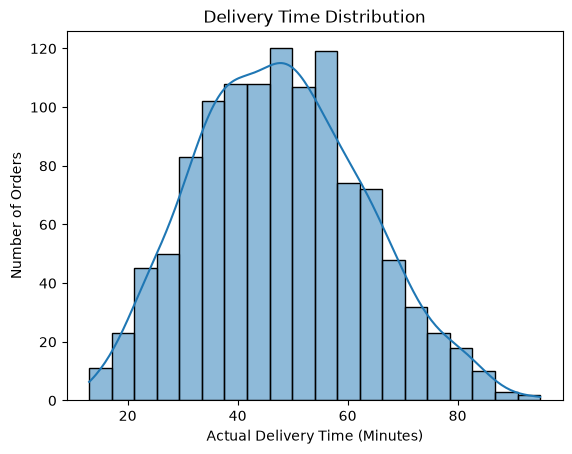

In [42]:
sns.histplot(orders["actual_delivery_mins"].dropna(),kde=True)
plt.title("Delivery Time Distribution")
plt.xlabel("Actual Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.show()

In [43]:
delivered=orders[orders["order_status"]=="Delivered"] 
delay_area=(delivered.groupby("delivery_area").agg(total_orders=("order_id","count"),
                                                   delayed_orders=("is_delayed",lambda x:(x == "Yes").sum())).reset_index())
delay_area["delay_rate"]=(delay_area["delayed_orders"]/delay_area["total_orders"]*100)

In [44]:
delivered.head()

,order_id,order_date,order_time,day_of_week,is_peak_hour,customer_id,delivery_area,item_id,item_name,category,...,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,is_delayed,order_status,delivery_partner_id,customer_rating,order_hour,delivery_speed_score
0,ORD00001,2025-04-21,1900-01-01 21:28:00,Monday,Yes,CUST0254,Sundarapuram,ITM008,Gobi Manchurian,Starters,...,5.4,50,51.0,1.0,Yes,Delivered,DP013,4.0,21,98.04
1,ORD00002,2025-08-31,1900-01-01 10:05:00,Sunday,No,CUST0068,Peelamedu,ITM018,Idli Sambar,South Indian,...,1.8,35,18.0,0.0,No,Delivered,DP012,5.0,10,194.44
2,ORD00003,2025-03-04,1900-01-01 21:22:00,Tuesday,Yes,CUST0241,Ukkadam,ITM009,Egg Fried Rice,Rice & Noodles,...,10.5,50,87.0,37.0,Yes,Delivered,DP021,2.0,21,57.47
3,ORD00004,2025-03-21,1900-01-01 23:14:00,Friday,No,CUST0139,Town Hall,ITM012,Veg Thali,Combo,...,4.7,35,39.0,4.0,Yes,Delivered,DP020,4.0,23,89.74
4,ORD00005,2025-05-17,1900-01-01 08:11:00,Saturday,No,CUST0053,Ukkadam,ITM017,Prawn Curry,Main Course,...,8.7,50,46.0,0.0,No,Delivered,DP004,1.0,8,108.70


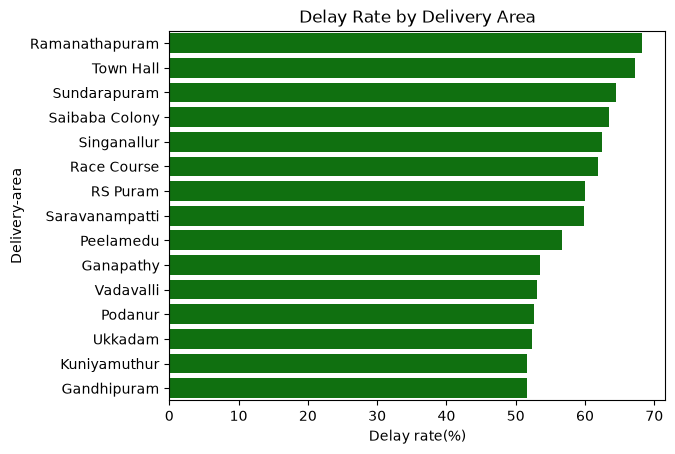

In [45]:
sns.barplot(data=delay_area.sort_values("delay_rate",ascending=False),
           x="delay_rate",
           y="delivery_area",color="green")
plt.title("Delay Rate by Delivery Area")
plt.xlabel("Delay rate(%)")
plt.ylabel("Delivery-area")
plt.show()

In [46]:
top_items = (delivered.groupby("item_name").agg(revenue=("total_amount_inr","sum"),orders=("order_id","count"))
.sort_values("revenue",ascending=False)
.head(10)
.reset_index())

In [47]:
top_items.head()

,item_name,revenue,orders
0,Mutton Rogan Josh,48320,55
1,Chicken Biryani,28340,39
2,Prawn Curry,27000,42
3,Chicken Thali,25000,41
4,Veg Thali,25000,48


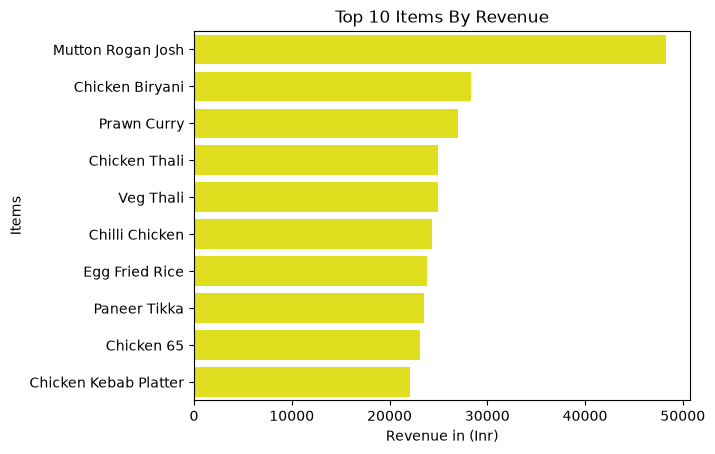

In [48]:
sns.barplot(data=top_items,x="revenue",y="item_name",color="yellow")
plt.title("Top 10 Items By Revenue")
plt.xlabel("Revenue in (Inr)")
plt.ylabel("Items")
plt.show()

In [49]:
hourly_orders= (orders.groupby("order_hour").size().reset_index(name="orders"))

In [50]:
hourly_orders.head()

,order_hour,orders
0,8,77
1,9,63
2,10,67
3,11,73
4,12,81


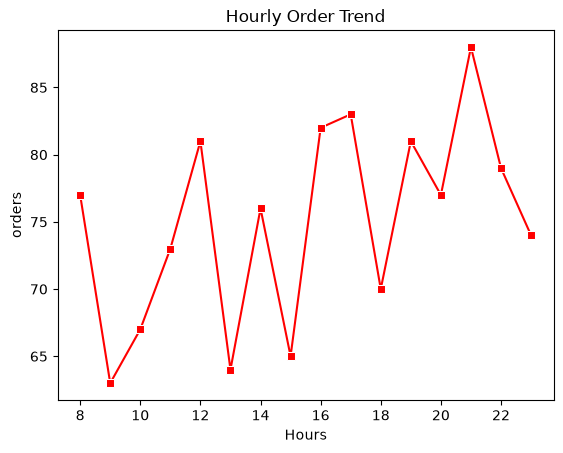

In [51]:
sns.lineplot(data= hourly_orders,x ="order_hour",y ="orders",marker="s",color="red")
plt.title("Hourly Order Trend")
plt.xlabel("Hours")
plt.ylabel("orders")
plt.show()

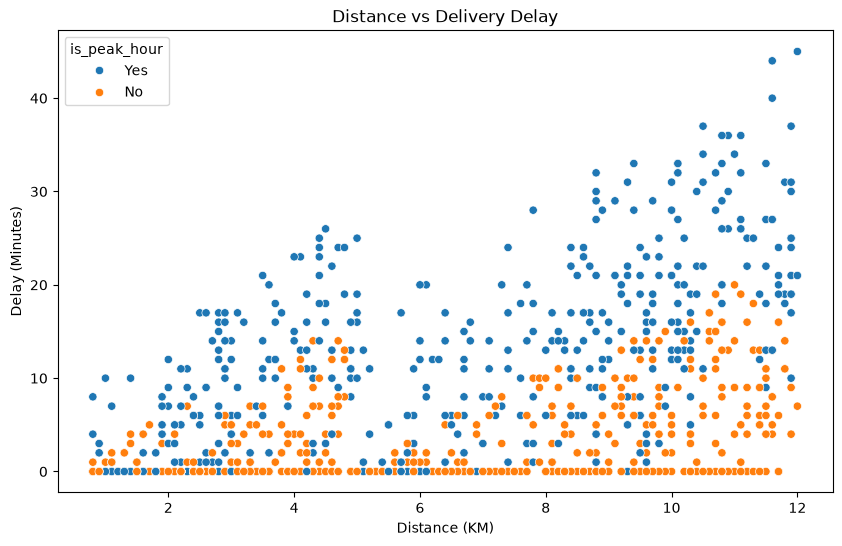

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=delivered,x="distance_km",y="delay_mins",hue="is_peak_hour",color="lime")
plt.title("Distance vs Delivery Delay")
plt.xlabel("Distance (KM)")
plt.ylabel("Delay (Minutes)")
plt.show()

In [53]:
partner_performance = (delivered.groupby("delivery_partner_id").agg(total_orders=("order_id", "count"),avg_delivery_time=("actual_delivery_mins", "mean"),
        avg_delay=("delay_mins", "mean"),avg_customer_rating=("customer_rating", "mean")).reset_index())

In [54]:
partner_performance.head()

,delivery_partner_id,total_orders,avg_delivery_time,avg_delay,avg_customer_rating
0,DP001,44,47.931818,6.863636,3.750000
1,DP002,42,50.500000,7.500000,3.952381
2,DP003,65,44.276923,4.830769,3.953846
3,DP004,49,49.367347,6.367347,3.612245
4,DP005,38,47.052632,6.710526,3.578947


In [55]:
partner_delay = (
    delivered.groupby("delivery_partner_id")["is_delayed"].apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="delay_rate"))
partner_performance = partner_performance.merge(partner_delay,on="delivery_partner_id")

In [56]:
partner_delay.head()

,delivery_partner_id,delay_rate
0,DP001,56.818182
1,DP002,59.523810
2,DP003,46.153846
3,DP004,69.387755
4,DP005,50.000000


In [57]:
item_performance = (delivered.groupby(["item_id", "item_name", "category"]).agg(order_volume=("order_id", "count"),
        revenue=("total_amount_inr", "sum"),
        avg_rating=("customer_rating", "mean"),
        delay_rate=("is_delayed",lambda x: (x == "Yes").mean() * 100))
    .reset_index())

In [58]:
item_performance.head()

,item_id,item_name,category,order_volume,revenue,avg_rating,delay_rate
0,ITM001,Paneer Butter Masala,Main Course,29,16560,4.000000,58.620690
1,ITM002,Chicken Biryani,Biryani,39,28340,3.717949,61.538462
2,ITM003,Veg Fried Rice,Rice & Noodles,41,14880,3.804878,56.097561
3,ITM004,Chicken 65,Starters,40,23100,3.575000,67.500000
4,ITM005,Butter Naan,Breads,48,5080,3.979167,45.833333


In [59]:
def performance(row):

    if (
        row["avg_rating"] >= 4.5
        and row["order_volume"] >= item_performance["order_volume"].median()
        and row["delay_rate"] <= item_performance["delay_rate"].median()
    ):
        return "High"

    elif (
        row["avg_rating"] >= 4
        and row["order_volume"] >= item_performance["order_volume"].median()
    ):
        return "Medium"

    else:
        return "Low"

item_performance["performance"] = item_performance.apply(
    performance,
    axis=1
)

In [60]:
item_performance[item_performance["performance"]=="Medium"]

,item_id,item_name,category,order_volume,revenue,avg_rating,delay_rate,performance
6,ITM007,Mutton Rogan Josh,Main Course,55,48320,4.181818,61.818182,Medium


In [61]:
orders.to_csv("cleaned_orders.csv",index=False)
menu.to_csv("cleaned_menu.csv",index=False)
customers.to_csv("cleaned_customers.csv",index=False)
partners.to_csv("cleaned_partners.csv",index=False)
reviews.to_csv("cleaned_reviews.csv",index=False)
item_performance.to_csv("item_performance.csv",index=False)
partner_performance.to_csv("partner_performance.csv",index=False)
print("Files exported!")

Files exported!


In [62]:
import os

print(os.getcwd())

C:\Users\ELCOT
